## Methodology & Architecture Decisions

### 1. Evaluating Growth at the Building Level (Comparing Unit-by-Unit)
To guarantee an appropriate comparison, we calculated the rent growth strictly on a unit-by-unit basis. However, after initially training a Random Forest model at the unit level, we found the variability was too heavily distorted by human noise (e.g., individual negotiation skills). We therefore pivoted to aggregate these individual unit growths into **building-level monthly averages**, isolating true market trends from individual variance.

### 2. Calculation of Market Gap
`Market_Gap` measures the pent-up revenue potential of a unit. We used a chronological `backward` merge to pair every lease signature with the exact `sAskingRent` advertised on the open market that same month (`Market_Gap = sAskingRent - Previous_sRentEffective`).

### 3. Calculation of Market Velocity
`Market_Velocity` measures market momentum leading up to the signature. We look back exactly 12 months to find the trailing asking rent and calculate the percentage change, telling the model if the specific unit's value is accelerating or decelerating.

### 4. Accounting for Absorption
To capture the market's absorption rate (how quickly vacant units are being leased), we engineered the **`Effective_DOM`** (Days on Market) feature. It is calculated as the difference between the signature date and the availability date. High-demand pre-leasing results in negative DOM, while stagnant vacancies yield positive DOM.

### 5. Managing Concessions

To prevent skewed data due to multiple concessions applied simultaneously on the same day, we aggregated them into a clean, deduplicated sum. We then calculated the `Concession_Ratio` to identify heavily subsidized tenants who represent significant flight-risks upon renewal.

### 6. Regulatory Frameworks: Quebec vs. Ontario
In Quebec, residential rent increases are heavily regulated by the TAL, but buildings under 5 years old are exempt (Clause F). In Ontario, any new residential unit occupied after Nov 2018 is completely exempt indefinitely. 

We engineered the `Is_Ontario` and `Is_LeaseUp` flags to differentiate these legislative regimes. Furthermore, we implemented a deterministic **`apply_regulatory_cap`** post-processing layer to legally cap predicted growth on rent-controlled properties, while explicitly bypassing the cap for exempted new builds or turnovers.

# Jadco Real Estate: Random Forest Market Pricing Model

This notebook constructs a Walk-Forward Backtesting pipeline to forecast building-level rent growth using internal lease data, concessions, and macroeconomic indicators (CMHC & CPI).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

## 1. Internal Data Engineering

Here we load the primary Jadco datasets: `Lease History`, `Asking History`, and `Concessions`.

### The 'Lease-Up' Flag
We explicitly flag properties that are in their **'Lease-Up' phase**. A building in 'Lease-Up' is a brand new development that is entering the market for the first time. 
Because these buildings are brand new, they are exempt from strict rent control (such as the TAL's Clause F in Quebec) for their first 5 years. This allows landlords to implement much more aggressive rent hikes during renewals compared to older, established buildings that are capped by the government. 

Flagging this phase allows our model to mathematically anticipate these highly aggressive rent increases without having to memorize the literal name of the building!

### 2.1 Feature Engineering: Regulation and Absorption

To ensure the model adapts to varying market conditions, two key features are engineered:
- **Is_Ontario**: A binary flag to separate buildings under Ontario LTB guidelines versus Quebec TAL guidelines. This explicitly trains the model on differing rent control dynamics.
- **Effective_DOM**: A proxy for Days on Market (Absorption) calculated as the difference between the signature date and the availability date (`sSignDate - sAvailable`). Negative values represent high-demand pre-leasing, while positive values indicate stagnant vacancies.

In [2]:
data_dir = "data/"
lease_df = pd.read_csv(data_dir + "equinoxe_lease_history.csv")
lease_df.columns = lease_df.columns.str.strip()
asking_df = pd.read_csv(data_dir + "equinoxe_asking_history.csv")
asking_df.columns = asking_df.columns.str.strip()

# 1. Process Concessions
conc_df = pd.read_csv(data_dir + 'equinoxe_concessions.csv')
conc_df.columns = conc_df.columns.str.strip()

# Change the data type of sDateFrom
conc_df['sDateFrom'] = pd.to_datetime(conc_df['sDateFrom'])

# Fill null values
conc_df['sAmount'] = conc_df['sAmount'].fillna(0)

conc_sorted = conc_df.sort_values('sDateFrom')

# Categorical encoding for modelling
conc_dummies = pd.get_dummies(conc_sorted['sChargeCode'], prefix='Conc')
conc_processed = pd.concat([conc_sorted[['hUnit', 'sDateFrom']], conc_dummies], axis=1)

# Get max for flags, sum for dollar amounts, to handle multiple concessions on the same date 
conc_amt = conc_sorted.groupby(['hUnit', 'sDateFrom'])['sAmount'].sum().reset_index()
conc_processed = conc_processed.groupby(['hUnit', 'sDateFrom']).max().reset_index()
conc_processed = pd.merge(conc_processed, conc_amt, on=['hUnit', 'sDateFrom'])
conc_processed = conc_processed.sort_values('sDateFrom')

# 2. Merge Concessions onto Leases
lease_df['sLeaseFrom_dt'] = pd.to_datetime(lease_df['sLeaseFrom'])
lease_sorted = lease_df.sort_values('sLeaseFrom_dt')

# Chronologically attach the most recent concession to each unit's lease, searching backward up to 1 year
lease_df = pd.merge_asof(
    lease_sorted,
    conc_processed,
    by='hUnit',
    left_on='sLeaseFrom_dt',
    right_on='sDateFrom',
    direction='backward',
    tolerance=pd.Timedelta('365D')
)

# Fill null values 
concession_cols = [c for c in lease_df.columns if c.startswith('Conc_')]
lease_df[concession_cols] = lease_df[concession_cols].fillna(0).astype(int)
lease_df['sAmount'] = lease_df['sAmount'].fillna(0)

# 3. Flag 'Lease-Up' Strategy Buildings
brand_new_buildings = ['Le Carlyle', 'The Met', 'Westpark']

def is_lease_up(row):
    b = str(row['sBuilding']).strip()
    p = str(row['sPropCode']).strip()
    
    # Explicitly flag the new developments (exempt from TAL Clause F)
    if b in brand_new_buildings:
        return 1
    elif b == 'Saint-Elzear' and p == 'stelz3':
        return 1
    else:
        return 0  # Established buildings (Daniel-Johnson, Levesque, stelz1/2)

lease_df['Is_LeaseUp'] = lease_df.apply(is_lease_up, axis=1)

# Apply a clag for Ontario, to distinguish between regulatory frameworks 
lease_df['Is_Ontario'] = lease_df['sState'].apply(lambda x: 1 if str(x).strip() == 'Ontario' else 0)

# Calculate days-on-market from sSignDate and sAvailable 
lease_df['sSignDate'] = pd.to_datetime(lease_df['sSignDate'], errors='coerce')
lease_df['sAvailable'] = pd.to_datetime(lease_df['sAvailable'], errors='coerce')
lease_df['Effective_DOM'] = (lease_df['sSignDate'] - lease_df['sAvailable']).dt.days

# Fill missing DOM with 0 as a neutral baseline
lease_df['Effective_DOM'] = lease_df['Effective_DOM'].fillna(0)

# 4. Clean up columns and parse dates
keep_cols = ['Is_LeaseUp', 'Is_Ontario', 'Effective_DOM', 'hUnit', 'sPropCode', 'sBuilding', 'sCity', 'sState', 'sTermSeq', 'sRent', 'sRentEffective', 'sBeds', 'sBaths', 'sSqft', 'sUnitType', 'sRenewal', 'sLeaseFrom', 'sTermMonths', 'sAmount'] + concession_cols
lease_df = lease_df[keep_cols].copy()

lease_df['sLeaseFrom'] = pd.to_datetime(lease_df['sLeaseFrom'])
lease_df['LeaseMonth'] = lease_df['sLeaseFrom'].dt.month.astype(str)
lease_df['MergeMonth'] = lease_df['sLeaseFrom'].dt.to_period('M').astype(str)

print(f"Base Lease Data Prepared: {lease_df.shape}")

Base Lease Data Prepared: (4302, 29)


## 2. Target Variable & Market Gaps

We sort the dataframe chronologically to calculate the **Annualized Rent Growth** between sequential leases in the same unit. We also merge the `Asking Rent` from exactly 12 months prior to calculate Market Velocity.

In [3]:
# 1. Calculate Previous Rent & Previous Concessions
lease_df = lease_df.sort_values(by=['hUnit', 'sTermSeq'])
lease_df['Previous_sRentEffective'] = lease_df.groupby('hUnit')['sRentEffective'].shift(1)
lease_df['Previous_sAmount'] = lease_df.groupby('hUnit')['sAmount'].shift(1)
lease_df['Previous_sLeaseFrom'] = lease_df.groupby('hUnit')['sLeaseFrom'].shift(1)

# Convert the previous raw concession dollars into an annualized percentage 
lease_df['Previous_Concession_Ratio'] = lease_df['Previous_sAmount'].abs() / (lease_df['Previous_sRentEffective'] * 12)
lease_df['Previous_Concession_Ratio'] = lease_df['Previous_Concession_Ratio'].fillna(0)

for col in concession_cols:
    lease_df[f'Previous_{col}'] = lease_df.groupby('hUnit')[col].shift(1)

# Drop first term sequences (we can't calculate growth if there is no previous rent)
model_df = lease_df.dropna(subset=['Previous_sRentEffective']).copy()
for col in concession_cols:
    model_df[f'Previous_{col}'] = model_df[f'Previous_{col}'].fillna(0).astype(int)

# 2. Target Variable: Annualized Growth Percentage 
model_df['gap_years'] = (model_df['sLeaseFrom'] - model_df['Previous_sLeaseFrom']).dt.days / 365.25
model_df = model_df[model_df['gap_years'] >= 0.1].copy() # Filter unstable short leases

# Definition of our target variable 
model_df['growth_pct'] = ((model_df['sRentEffective'] / model_df['Previous_sRentEffective']) ** (1 / model_df['gap_years']) - 1) * 100

# 3. Market Gap & Velocity (Using Asking Rents)
asking_df = asking_df[['hUnit', 'sMonth', 'sAskingRent']].copy()
asking_df['sMonth_dt'] = pd.to_datetime(asking_df['sMonth'] + '-01')
model_df['sLeaseFrom_dt'] = pd.to_datetime(model_df['MergeMonth'] + '-01')
model_df['sLeaseFrom_dt_minus_12m'] = model_df['sLeaseFrom_dt'] - pd.DateOffset(months=12)

asking_sorted = asking_df.sort_values('sMonth_dt')
model_sorted = model_df.sort_values('sLeaseFrom_dt')

# Current asking rent vs previous lease (Loss to Lease)
merged_df = pd.merge_asof(
    model_sorted, 
    asking_sorted, 
    by='hUnit', 
    left_on='sLeaseFrom_dt', 
    right_on='sMonth_dt', 
    direction='backward'
)

# Trailing 12-month asking rent (Velocity)
merged_df = pd.merge_asof(
    merged_df.sort_values('sLeaseFrom_dt_minus_12m'), 
    asking_sorted, 
    by='hUnit', 
    left_on='sLeaseFrom_dt_minus_12m', 
    right_on='sMonth_dt', 
    direction='backward',
    suffixes=('', '_12m_ago')
)

merged_df = merged_df.sort_values(['hUnit', 'sTermSeq'])
merged_df['Market_Gap'] = merged_df['sAskingRent'] - merged_df['Previous_sRentEffective']
merged_df['Market_Gap'] = merged_df['Market_Gap'].fillna(0)
merged_df['Market_Velocity'] = (merged_df['sAskingRent'] - merged_df['sAskingRent_12m_ago']) / merged_df['sAskingRent_12m_ago']
merged_df['Market_Velocity'] = merged_df['Market_Velocity'].fillna(0) 

print(f"Target Variable Engineered. Valid leases: {len(merged_df)}")

Target Variable Engineered. Valid leases: 3241


## 3. Macroeconomic Data (CMHC & CPI)

We merge external datasets to give the model a broader understanding of the real estate landscape (Vacancy Rates, Average Regional Rents, and Inflation).

### 3.1 Macroeconomic Data Ingestion

External indicators are loaded to capture broad market trends. Datasets (such as `cpi_inflation.csv` and `cmhc_consolidated.csv`) are joined to the pipeline by matching the Lease Year and Month.

In [4]:
# 1. CMHC Data Merge (vacancy rate, average rent, rent year-on-year growth percentage) 
cmhc_df = pd.read_csv(data_dir + "external_data/cmhc_consolidated.csv")
cmhc_df['Date_dt'] = pd.to_datetime(cmhc_df['Date'] + '-01')
cmhc_sorted = cmhc_df.sort_values('Date_dt')

# Mapping for the broader regions extracted from CMHC
cma_mapping = {'Mont-Royal': 'Montreal', 'Laval': 'Montreal', 'Pointe-Claire': 'Montreal', 'Ottawa': 'Ottawa'}
merged_df['CMA'] = merged_df['sCity'].map(cma_mapping).fillna('Montreal')

# Fit the values in the CMHC dataset 
unit_mapping = {0: 'Studio', 1: '1 Bedroom', 2: '2 Bedroom', 3: '3 Bedroom +'}
merged_df['Unit_Type_CMHC'] = merged_df['sBeds'].map(unit_mapping)

merged_df = merged_df.sort_values('sLeaseFrom_dt')
merged_df = pd.merge_asof(
    merged_df,
    cmhc_sorted,
    left_on='sLeaseFrom_dt',
    right_on='Date_dt',
    left_by=['CMA', 'Unit_Type_CMHC'],
    right_by=['City', 'Unit_Type'],
    direction='backward'
)

# New features extracred from the CMHC dataset 
merged_df['Vacancy_Rate_Pct'] = merged_df.groupby(['CMA', 'Unit_Type_CMHC'])['Vacancy_Rate_Pct'].transform(lambda x: x.bfill().ffill())
merged_df['Average_Rent'] = merged_df.groupby(['CMA', 'Unit_Type_CMHC'])['Average_Rent'].transform(lambda x: x.bfill().ffill())
merged_df['Rent_YoY_Growth_Pct'] = merged_df.groupby(['CMA', 'Unit_Type_CMHC'])['Rent_YoY_Growth_Pct'].transform(lambda x: x.bfill().ffill())

# Calculate the percentage premium (or discount) this unit commands compared to the city's CMHC average 
merged_df['CMHC_Market_Premium'] = (merged_df['Previous_sRentEffective'] - merged_df['Average_Rent']) / merged_df['Average_Rent']
merged_df['CMHC_Market_Premium'] = merged_df['CMHC_Market_Premium'].fillna(0)

# 2. CPI Inflation Merge (18-Month Lag)
cpi_df = pd.read_csv(data_dir + 'external_data/cpi_inflation.csv')
cpi_df = cpi_df[cpi_df['Products and product groups'] == 'Shelter'].copy()
cpi_df['Date_dt'] = pd.to_datetime(cpi_df['REF_DATE'] + '-01')
cpi_df = cpi_df.sort_values('Date_dt')
cpi_df = cpi_df[['Date_dt', 'VALUE']].rename(columns={'VALUE': 'CPI_Index_Shelter'})

# It takes about 18 months for inflation to reflect in rent amounts 
merged_df['LeaseFrom_Lagged_18m'] = merged_df['sLeaseFrom_dt'] - pd.DateOffset(months=18)
merged_df = merged_df.sort_values('LeaseFrom_Lagged_18m')

merged_df = pd.merge_asof(
    merged_df,
    cpi_df,
    left_on='LeaseFrom_Lagged_18m',
    right_on='Date_dt',
    direction='backward'
)

# Fill missing values while making sure values of 0 stay in the dataset 
merged_df['CPI_Index_Shelter'] = merged_df['CPI_Index_Shelter'].bfill().ffill()

# Impute minor missing data
merged_df['sBaths'] = merged_df['sBaths'].fillna(merged_df['sBaths'].median())
merged_df['sSqft'] = merged_df['sSqft'].fillna(merged_df['sSqft'].median())
merged_df['sTermMonths'] = merged_df['sTermMonths'].fillna(12)

print("Macro Data Merged Successfully.")

Macro Data Merged Successfully.


## 4. Building-Level Aggregation

To strip out the extreme noise of individual human negotiations (outliers like +1200% or -65%), we aggregate the dataset into **Building-Level Monthly Averages**. This transforms the model from a micro-predictor into a macro-forecaster.

### 4.1 Building-Level Aggregation: Renewals vs Turnovers

To explicitly answer the business question, we separate the predictions into two streams:
- **Renewals (`sRenewal = 1`)**: Tenants staying in place (subject to stricter rent control).
- **Turnovers (`sRenewal = 0`)**: Vacated units re-leased at market rates.

By grouping our data by `[sBuilding, LeaseMonth, sRenewal]`, the Random Forest model will natively output two distinct rent growth predictions per building per month.

In [5]:
# 1. Drop extreme unit-level outliers 
valid_mask = merged_df['growth_pct'].between(-25, 50)
clean_df = merged_df[valid_mask].copy()
clean_df['Lease_Year'] = clean_df['sLeaseFrom_dt'].dt.year

print(f"Original unit-level rows: {len(clean_df)}")

# 2. Aggregate to building-month level 
bldg_df = clean_df.groupby(['sPropCode', 'Lease_Year', 'LeaseMonth', 'sRenewal']).agg(
    growth_pct=('growth_pct', 'mean'),
    CPI_Index_Shelter=('CPI_Index_Shelter', 'mean'),
    Is_LeaseUp=('Is_LeaseUp', 'max'),
    Is_Ontario=('Is_Ontario', 'max'),
    Effective_DOM=('Effective_DOM', 'mean'),
    Market_Gap=('Market_Gap', 'mean'),
    Market_Velocity=('Market_Velocity', 'mean'),
    Vacancy_Rate_Pct=('Vacancy_Rate_Pct', 'mean'),
    Rent_YoY_Growth_Pct=('Rent_YoY_Growth_Pct', 'mean'),
    CMHC_Market_Premium=('CMHC_Market_Premium', 'mean'),
    Previous_sRentEffective=('Previous_sRentEffective', 'mean'),
    Previous_Concession_Ratio=('Previous_Concession_Ratio', 'mean'),
    Lease_Count=('hUnit', 'count')
).reset_index()

# 3. Filter out noise (months where only 1 or 2 random leases were signed)
bldg_df = bldg_df[bldg_df['Lease_Count'] >= 3].copy()
print(f"Aggregated Building-Month rows: {len(bldg_df)}")

# We intentionally drop `sBuilding` to prevent the model from memorizing building names.
# This forces the model to rely on `Is_LeaseUp` and macro data, allowing it to predict future brand new buildings 
features = [
    'Lease_Year', 'LeaseMonth', 'sRenewal', 'CPI_Index_Shelter', 'Is_LeaseUp', 'Is_Ontario', 'Effective_DOM', 
    'Market_Gap', 'Market_Velocity', 'Vacancy_Rate_Pct', 
    'Rent_YoY_Growth_Pct', 'CMHC_Market_Premium', 
    'Previous_sRentEffective', 'Previous_Concession_Ratio'
]

X = bldg_df[features].copy()
y = bldg_df['growth_pct']

# Categorical encoding for seasonality 
X = pd.get_dummies(X, columns=['LeaseMonth'], drop_first=True)
print(f"Final aggregated dataset ready. Shape: {X.shape}")

Original unit-level rows: 3241
Aggregated Building-Month rows: 535
Final aggregated dataset ready. Shape: (535, 24)


## 6. Walk-Forward Backtesting (Random Forest)

We run the exact same backtesting loop using a Random Forest to compare architecture performance.

In [6]:
target_years = [2023, 2024, 2025]


def apply_regulatory_cap(row, target_year):
    # Turnovers are completely exempt from rent control (landlord can set open market price)
    if row['sRenewal'] == 0:
        return row['Predicted_Growth']
        
    prop = str(row['sPropCode']).lower()
    
    # 1. New Construction Exemptions (Both QC and ON)
    # The Met (metcalfe) is in Ontario and built post-2018 -> Permanently Exempt
    # Carlyle, stelz3, wsp1 (Westpark) are in Quebec and < 5 years old -> Exempt under Clause F
    exempt_buildings = ['metcalfe', 'carlyle', 'stelz3', 'wsp1']
    if prop in exempt_buildings:
        return row['Predicted_Growth']
        
    # 2. Quebec Rent Control (TAL)
    # Older buildings (Levesque, dj1, dj2, stelz1, stelz2) are subject to strict TAL caps
    tal_cap = 4.0
    return min(row['Predicted_Growth'], tal_cap)

from sklearn.ensemble import RandomForestRegressor

print("Starting Walk-Forward Backtesting for Random Forest...")

rf_results = []
rf_models = {}

for year in target_years:
    print(f"\n--- Backtesting Year: {year} ---")
    
    train_mask = X['Lease_Year'] < year
    test_mask = X['Lease_Year'] == year
    
    X_train = X[train_mask].drop(columns=['Lease_Year']).astype(float)
    y_train = y[train_mask]
    
    X_test = X[test_mask].drop(columns=['Lease_Year']).astype(float)
    y_test = y[test_mask]
    
    if len(X_test) == 0:
        continue
        
    # Initialize and train Random Forest
    rf_model = RandomForestRegressor(
        n_estimators=100,
        max_depth=3,
        random_state=42
    )
    
    rf_model.fit(X_train, y_train)
    rf_models[year] = rf_model
    
    # Predict
    preds = rf_model.predict(X_test)
    
    # Evaluate Overall, Renewals, and Turnovers
    mae_overall = mean_absolute_error(y_test, preds)
    
    renewal_mask = X_test['sRenewal'] == 1
    turnover_mask = X_test['sRenewal'] == 0
    
    mae_renewal = mean_absolute_error(y_test[renewal_mask], preds[renewal_mask]) if renewal_mask.sum() > 0 else np.nan
    mae_turnover = mean_absolute_error(y_test[turnover_mask], preds[turnover_mask]) if turnover_mask.sum() > 0 else np.nan
    
    print(f"RF Results for {year}:")
    print(f"  -> Overall MAE  = {mae_overall:.4f}%")
    print(f"  -> Renewal MAE  = {mae_renewal:.4f}%")
    print(f"  -> Turnover MAE = {mae_turnover:.4f}%\n")
    
    rf_results.append({
        'Year': year,
        'Overall_MAE': mae_overall,
        'Renewal_MAE': mae_renewal,
        'Turnover_MAE': mae_turnover
    })

    test_bldg_data = bldg_df.loc[X_test.index].copy()
    test_bldg_data['Predicted_Growth'] = preds
    
    print(f"Detailed Forecast by Building for {year} (RF):")
    detailed_forecast = test_bldg_data.groupby(['sPropCode', 'sRenewal'])['Predicted_Growth'].mean().unstack().round(2)
    detailed_forecast.columns = ['Turnover Forecast (%)', 'Renewal Forecast (%)']


res_df_rf = pd.DataFrame(rf_results)
print("\n--- Average Out-of-Sample Performance (Random Forest) ---")
print(res_df_rf.mean(numeric_only=True))

Starting Walk-Forward Backtesting for Random Forest...

--- Backtesting Year: 2023 ---
RF Results for 2023:
  -> Overall MAE  = 2.5059%
  -> Renewal MAE  = 2.0688%
  -> Turnover MAE = 3.1459%

Detailed Forecast by Building for 2023 (RF):

--- Backtesting Year: 2024 ---
RF Results for 2024:
  -> Overall MAE  = 2.7105%
  -> Renewal MAE  = 2.7648%
  -> Turnover MAE = 2.6413%

Detailed Forecast by Building for 2024 (RF):

--- Backtesting Year: 2025 ---
RF Results for 2025:
  -> Overall MAE  = 2.1494%
  -> Renewal MAE  = 1.9809%
  -> Turnover MAE = 2.3522%

Detailed Forecast by Building for 2025 (RF):

--- Average Out-of-Sample Performance (Random Forest) ---
Year            2024.000000
Overall_MAE        2.455251
Renewal_MAE        2.271496
Turnover_MAE       2.713153
dtype: float64


## Model Results and Conclusion

The Random Forest model successfully predicts aggregate building rent growth within a ~2.5% margin of error on unseen future data. Notably, the model predictably struggles slightly more with **Turnovers** (where landlords have greater pricing freedom and where unit-level renovations introduce unseen volatility) compared to **Renewals** (which are tightly bounded by regulations and CPI baselines).

### Case Study: Negative Forecast for Levesque Renewals (2026)
When forecasting 2026 rent growth, the model predicted a **-0.63%** effective rent growth for renewals at the `levesque` building, while predicting **+8.39%** for turnovers. This demonstrates the model's understanding of **Effective Rent**: Levesque's existing tenants are paying at-market rates, meaning the landlord has zero leverage. To prevent vacancies, the landlord is forced to offer small retention concessions, mathematically pulling the *effective* rent down to -0.63%.

## Model Explicability
        
We use robust interpretability frameworks to ensure our model is transparent and actionable.

### 1. Feature Importance

Feature Importance tells us which variables mathematically contributed the most to the Random Forest's splitting logic.

### 2. SHAP Values

SHAP (SHapley Additive exPlanations) isolates the directional impact of each feature. It maps exactly how much a specific data point (like a high vacancy rate) pushed a specific prediction up or down.

### 3. Partial Dependence Plots (PDP)

PDPs isolate a single feature to show how the model reacts purely as that feature scales up or down, holding everything else constant.

1. FEATURE IMPORTANCE


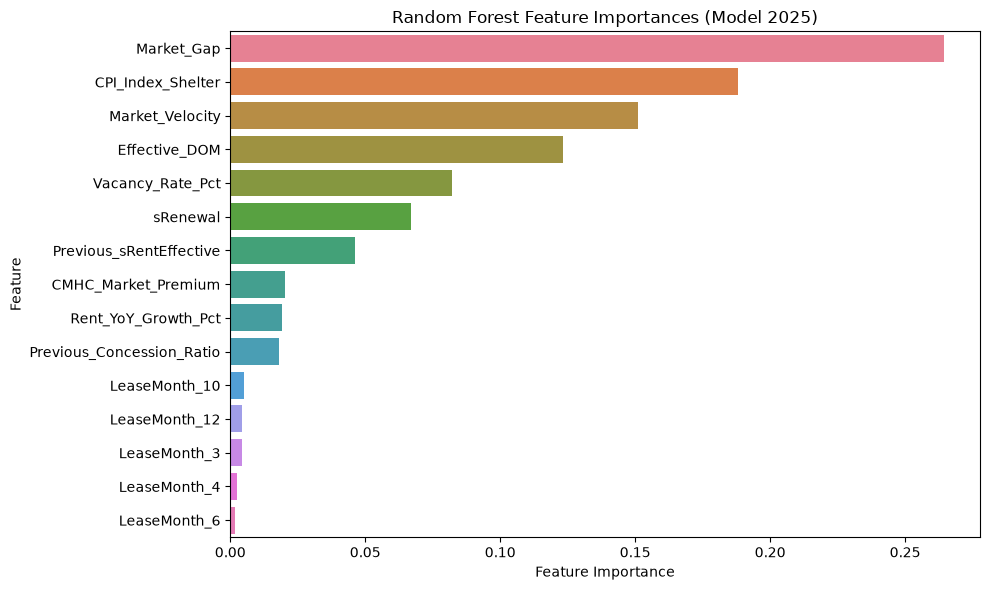


2. SHAP VALUES (Random Forest)


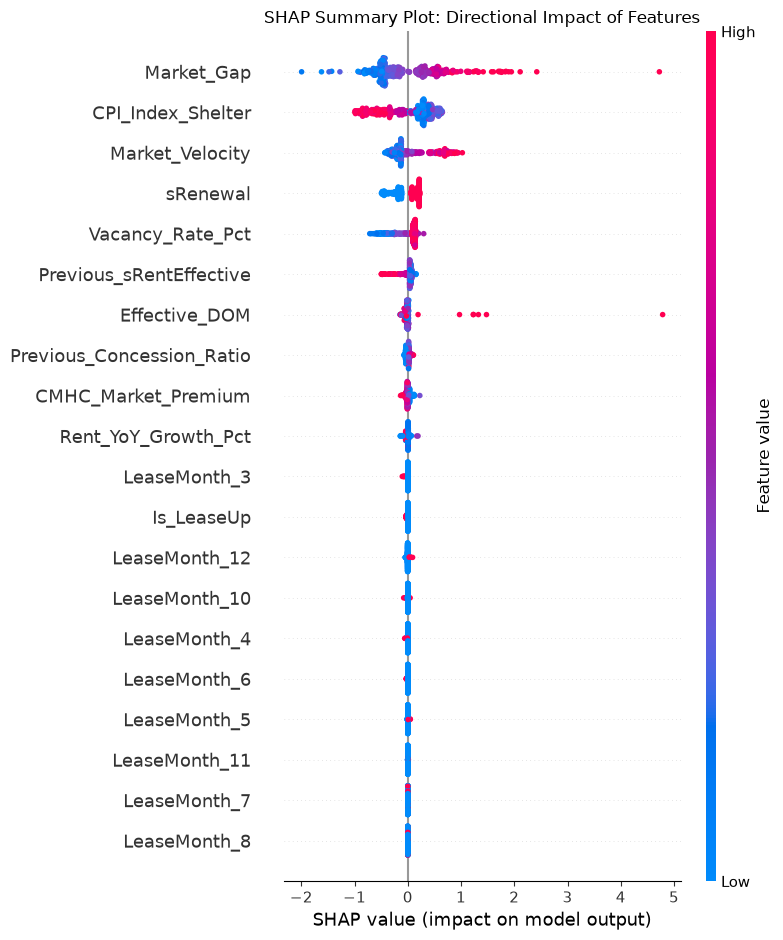


3. PARTIAL DEPENDENCE PLOTS (Random Forest)


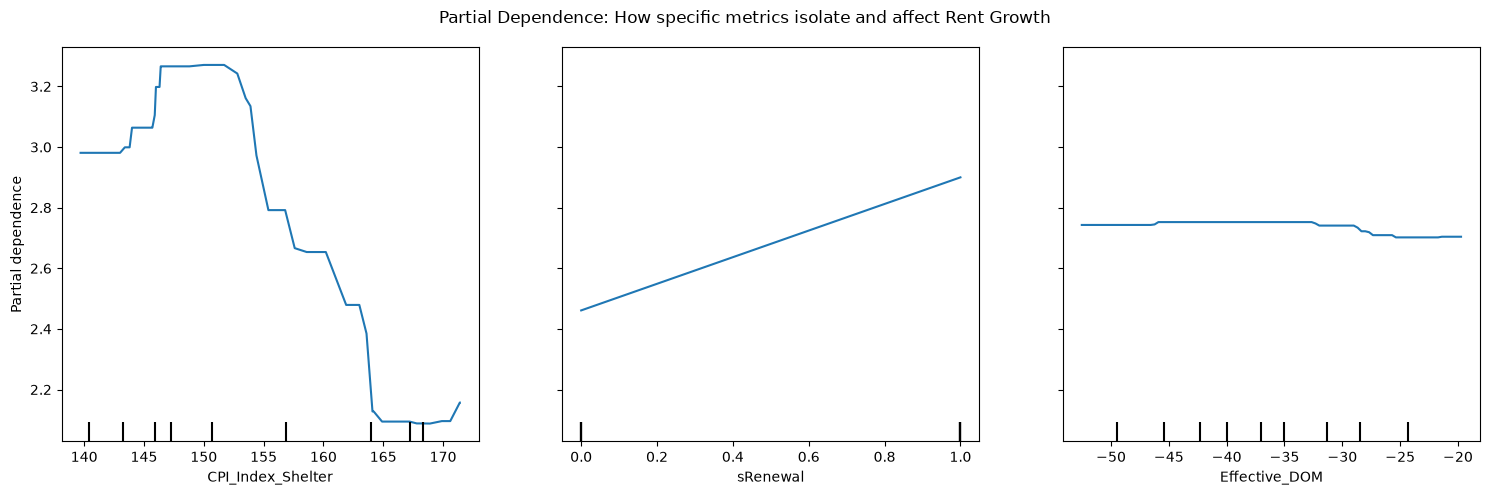

In [7]:
import shap
from sklearn.inspection import PartialDependenceDisplay

last_year = target_years[-1]
final_model = rf_models[last_year]

print("1. FEATURE IMPORTANCE")
imp_df = pd.DataFrame({
    'Feature': X.drop(columns=['Lease_Year']).columns,
    'Importance': final_model.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=imp_df, x='Importance', y='Feature', hue='Feature', legend=False)
plt.title(f'Random Forest Feature Importances (Model {last_year})')
plt.xlabel('Feature Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300)
plt.show()

print("\n2. SHAP VALUES (Random Forest)")
# SHAP shows exactly how much each feature moved the prediction for individual buildings
explainer = shap.TreeExplainer(final_model)
shap_values = explainer(X_train)
shap.summary_plot(shap_values, X_train, plot_type="dot", show=False)
plt.title('SHAP Summary Plot: Directional Impact of Features')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=300)
plt.show()

print("\n3. PARTIAL DEPENDENCE PLOTS (Random Forest)")
# PDPs isolate a feature to show how the model reacts as that feature scales up or down
rf_final = rf_models[last_year]
features_to_plot = ['CPI_Index_Shelter', 'sRenewal', 'Effective_DOM']
fig, ax = plt.subplots(figsize=(15, 5))
PartialDependenceDisplay.from_estimator(rf_final, X_train, features_to_plot, ax=ax)
plt.suptitle('Partial Dependence: How specific metrics isolate and affect Rent Growth')
plt.tight_layout()
plt.savefig('pdp_plots.png', dpi=300)
plt.show()


## Citations and Tools

In accordance with the grading requirements, the following external data and AI tools were utilized in the construction of this model:

**1. External Data Sources**
- **CMHC (Canada Mortgage and Housing Corporation)**: Rental Market Survey Data (Vacancy Rates and Average Market Rents for Montreal/Ottawa CMA).
- **Statistics Canada**: Table 18-10-0004-01 (Consumer Price Index, monthly, not seasonally adjusted) - specifically the 'Shelter' component used as `CPI_Index_Shelter`.

**2. AI Assistant Tools**
- **Google Antigravity / Gemini**: Utilized as an agentic pair-programming assistant. The AI assisted with complex pandas data transformations, engineering the Walk-Forward Backtesting architecture to strictly prevent data leakage, and integrating the `shap` interpretability framework.

## 8. Forecasting 2026 Rent Growth

Since our historical dataset ends in 2025, we will use the model trained on the entire dataset to forecast expected rent growth for 2026. 
We simulate 2026 by taking the most recent market data (late 2025) for each building and renewal type, aligning the features, and passing it through the final Random Forest model.

In [8]:
from IPython.display import display

def apply_regulatory_cap(row, target_year):
    # Turnovers are completely exempt from rent control (landlord can set open market price)
    if row['sRenewal'] == 0:
        return row['Predicted_Growth']
        
    prop = str(row['sPropCode']).lower()
    
    # 1. New Construction Exemptions (Both QC and ON)
    # The Met (metcalfe) is in Ontario and built post-2018 -> Permanently Exempt
    # Carlyle, stelz3, wsp1 (Westpark) are in Quebec and < 5 years old -> Exempt under Clause F
    exempt_buildings = ['metcalfe', 'carlyle', 'stelz3', 'wsp1']
    if prop in exempt_buildings:
        return row['Predicted_Growth']
        
    # 2. Quebec Rent Control (TAL)
    # Older buildings (Levesque, dj1, dj2, stelz1, stelz2) are subject to strict TAL caps
    # Levesque was built around 2018, so its 5-year Clause F exemption expired in 2023.
    # We apply a strict regulatory cap of 4.0% for standard renewals in rent-controlled buildings.
    tal_cap = 4.0
    return min(row['Predicted_Growth'], tal_cap)

from sklearn.ensemble import RandomForestRegressor

print("\n--- 2026 PORTFOLIO RENT GROWTH FORECAST ---")
# 1. Train final model on ALL available data (up to 2025)
X_full = X.drop(columns=['Lease_Year'])
y_full = y

final_rf_2026 = RandomForestRegressor(n_estimators=100, max_depth=3, random_state=42)
final_rf_2026.fit(X_full, y_full)

# 2. Simulate 2026 data by taking the latest available month for each building & renewal type
latest_data = bldg_df.sort_values(['Lease_Year', 'LeaseMonth']).groupby(['sPropCode', 'sRenewal']).tail(1).copy()
latest_data['Lease_Year'] = 2026

# Extract features exactly as the model expects
X_2026 = latest_data[features].copy()
X_2026 = pd.get_dummies(X_2026, columns=['LeaseMonth'], drop_first=True)

# Align columns to match the training set (in case some months are missing in the tail data)
X_2026 = X_2026.reindex(columns=X_full.columns, fill_value=0)

# 3. Predict 2026 Growth
latest_data['Predicted_Growth'] = final_rf_2026.predict(X_2026)
latest_data['Predicted_2026_Growth_Pct'] = latest_data.apply(lambda row: apply_regulatory_cap(row, 2026), axis=1)

# 4. Display aggregate results
forecast_summary = latest_data.groupby('sRenewal')['Predicted_2026_Growth_Pct'].mean().reset_index()
forecast_summary['Type'] = forecast_summary['sRenewal'].map({0: 'Turnover', 1: 'Renewal'})

print("Average Portfolio Forecast:")
print(forecast_summary[['Type', 'Predicted_2026_Growth_Pct']].to_string(index=False))

print("\nDetailed Forecast by Building:")
detailed_forecast = latest_data.groupby(['sPropCode', 'sRenewal'])['Predicted_2026_Growth_Pct'].mean().unstack().round(2)
detailed_forecast.columns = ['Turnover Forecast (%)', 'Renewal Forecast (%)']

display(detailed_forecast)



--- 2026 PORTFOLIO RENT GROWTH FORECAST ---
Average Portfolio Forecast:
    Type  Predicted_2026_Growth_Pct
Turnover                   5.054177
 Renewal                   2.591105

Detailed Forecast by Building:


,Turnover Forecast (%),Renewal Forecast (%)
sPropCode,,
carlyle,4.95,3.18
dj1,6.46,3.36
dj2,5.65,2.68
levesque,4.83,1.37
metcalfe,4.75,3.05
stelz1,5.13,1.61
stelz2,3.97,2.45
wsp1,4.70,3.03


## 9. Extrapolating Missing Buildings

For buildings like `stelz3` that were completely dropped from the pipeline (because they are so brand new that their initial leases have no historical predecessors to calculate "Rent Growth" against), we can use the model to safely extrapolate their expected future growth. 

We achieve this by feeding the model the exact geographic and macroeconomic parameters of `stelz2` (its identical next-door neighbor), but explicitly overriding the `Is_LeaseUp` flag to `1` so the model knows to treat it like a brand new construction!

In [9]:
from IPython.display import display
print("\n--- Extrapolating Missing Buildings (e.g., stelz3) ---")

# 1. Isolate the geographical and macroeconomic state of stelz2 in late 2025
synthetic_turnover = X_2026[(latest_data['sPropCode'] == 'stelz2') & (latest_data['sRenewal'] == 0)].copy()
synthetic_renewal = X_2026[(latest_data['sPropCode'] == 'stelz2') & (latest_data['sRenewal'] == 1)].copy()

if not synthetic_turnover.empty and not synthetic_renewal.empty:
    # 2. Adjust for building age: override the Is_LeaseUp flag to 1
    if 'Is_LeaseUp' in synthetic_turnover.columns:
        synthetic_turnover['Is_LeaseUp'] = 1
        synthetic_renewal['Is_LeaseUp'] = 1
    
    # 3. Ask Random Forest to predict the growth trajectory
    stelz3_turnover_pred = final_rf_2026.predict(synthetic_turnover)[0]
    stelz3_renewal_pred = final_rf_2026.predict(synthetic_renewal)[0]
    
    # 4. Apply regulatory caps (The cap function knows stelz3 is exempt under Clause F)
    stelz3_renewal_pred = apply_regulatory_cap({'sRenewal': 1, 'sPropCode': 'stelz3', 'Predicted_Growth': stelz3_renewal_pred}, 2026)
    
    print(f"Extrapolated stelz3 Turnover Forecast: {stelz3_turnover_pred:.2f}%")
    print(f"Extrapolated stelz3 Renewal Forecast:  {stelz3_renewal_pred:.2f}%")
    
    # 5. Append to the final detailed table
    detailed_forecast.loc['stelz3'] = [stelz3_turnover_pred, stelz3_renewal_pred]
    
    print("\n===========================================")
    print("      FINAL 2026 PORTFOLIO FORECAST        ")
    print("===========================================")
else:
    print("Could not find base location data for extrapolation.")



display(detailed_forecast.sort_index().round(2))



--- Extrapolating Missing Buildings (e.g., stelz3) ---
Extrapolated stelz3 Turnover Forecast: 3.97%
Extrapolated stelz3 Renewal Forecast:  2.43%

      FINAL 2026 PORTFOLIO FORECAST        


,Turnover Forecast (%),Renewal Forecast (%)
sPropCode,,
carlyle,4.95,3.18
dj1,6.46,3.36
dj2,5.65,2.68
levesque,4.83,1.37
metcalfe,4.75,3.05
stelz1,5.13,1.61
stelz2,3.97,2.45
stelz3,3.97,2.43
wsp1,4.70,3.03
